In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load the processed features
processed_path = Path.cwd().parent / 'data' / 'processed'
df = pd.read_csv(processed_path / 'features.csv')

print("Shape:", df.shape)
print("\nTarget distribution:")
print(df['final_result'].value_counts())

Shape: (32593, 29)

Target distribution:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64


In [6]:
from sklearn.preprocessing import LabelEncoder

# Define which columns to use as features
feature_columns = [
    'gender_encoded',
    'disability_encoded', 
    'age_encoded',
    'education_encoded',
    'num_of_prev_attempts',
    'studied_credits',
    'total_clicks',
    'avg_daily_clicks',
    'active_days',
    'max_clicks_day',
    'early_clicks',
    'avg_score',
    'max_score',
    'min_score',
    'num_assessments',
    'num_late_submissions',
    'late_submission_rate',
    'stayed_enrolled',
    'avg_registration_date'
]

# Features (X) and target (y)
X = df[feature_columns]
y = df['final_result']

# Encode target variable to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Feature matrix shape:", X.shape)
print("\nTarget classes:", le.classes_)
print("Encoded as:", list(range(len(le.classes_))))

Feature matrix shape: (32593, 19)

Target classes: ['Distinction' 'Fail' 'Pass' 'Withdrawn']
Encoded as: [0, 1, 2, 3]


In [7]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # ensures equal class distribution in both sets
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining target distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(le.classes_, counts):
    print(f"  {cls}: {count}")

Training set size: (26074, 19)
Test set size: (6519, 19)

Training target distribution:
  Distinction: 2419
  Fail: 5641
  Pass: 9889
  Withdrawn: 8125


In [8]:
from sklearn.preprocessing import StandardScaler

# Scale features - important for many ML algorithms
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print("Mean of first feature (should be ~0):", X_train_scaled[:, 0].mean().round(4))
print("Std of first feature (should be ~1):", X_train_scaled[:, 0].std().round(4))

Features scaled successfully!
Mean of first feature (should be ~0): -0.0
Std of first feature (should be ~1): 1.0


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # handles class imbalance
    random_state=42,
    n_jobs=-1  # uses all CPU cores
)

rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Results
print("=== Random Forest Results ===\n")
print(classification_report(y_test, y_pred_rf, 
                           target_names=le.classes_))

=== Random Forest Results ===

              precision    recall  f1-score   support

 Distinction       0.61      0.44      0.51       605
        Fail       0.78      0.66      0.71      1411
        Pass       0.70      0.83      0.76      2472
   Withdrawn       0.89      0.86      0.87      2031

    accuracy                           0.77      6519
   macro avg       0.74      0.70      0.71      6519
weighted avg       0.77      0.77      0.76      6519



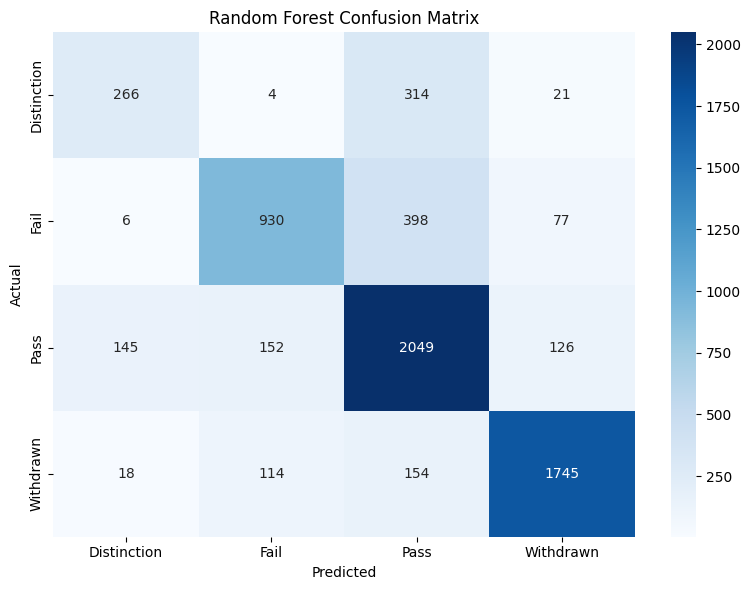

In [10]:
# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

/var/folders/78/fp6ycqwd4n33yk56_4fqw4w00000gn/T/ipykernel_13565/3878144428.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature',


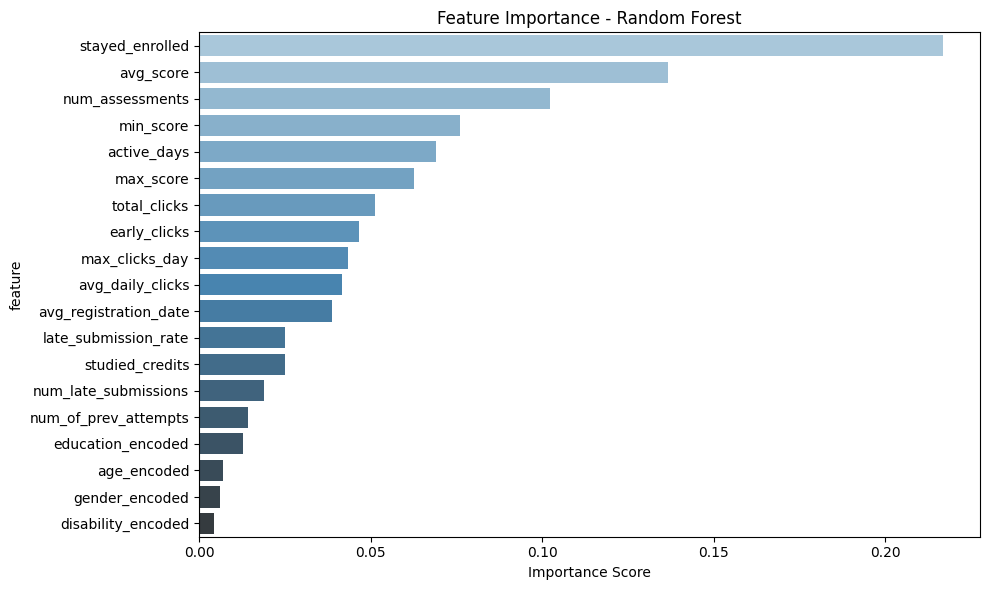


Top 5 most important features:
            feature  importance
17  stayed_enrolled    0.216772
11        avg_score    0.136781
14  num_assessments    0.102423
13        min_score    0.076161
8       active_days    0.069179


In [11]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature',
            palette='Blues_d')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance_df.head())

In [12]:
# Remove stayed_enrolled as it causes data leakage
feature_columns_clean = [
    'gender_encoded',
    'disability_encoded', 
    'age_encoded',
    'education_encoded',
    'num_of_prev_attempts',
    'studied_credits',
    'total_clicks',
    'avg_daily_clicks',
    'active_days',
    'max_clicks_day',
    'early_clicks',
    'avg_score',
    'max_score',
    'min_score',
    'num_assessments',
    'num_late_submissions',
    'late_submission_rate',
    'avg_registration_date'
]

# Retrain with clean features
X_clean = df[feature_columns_clean]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Scale
scaler_clean = StandardScaler()
X_train_c_scaled = scaler_clean.fit_transform(X_train_c)
X_test_c_scaled = scaler_clean.transform(X_test_c)

# Retrain model
rf_clean = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_clean.fit(X_train_c_scaled, y_train_c)
y_pred_clean = rf_clean.predict(X_test_c_scaled)

print("=== Random Forest Results (No Data Leakage) ===\n")
print(classification_report(y_test_c, y_pred_clean,
                           target_names=le.classes_))

=== Random Forest Results (No Data Leakage) ===

              precision    recall  f1-score   support

 Distinction       0.62      0.45      0.53       605
        Fail       0.51      0.37      0.43      1411
        Pass       0.69      0.83      0.76      2472
   Withdrawn       0.68      0.70      0.69      2031

    accuracy                           0.66      6519
   macro avg       0.63      0.59      0.60      6519
weighted avg       0.64      0.66      0.64      6519



In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train_c_scaled, y_train_c)
y_pred_gb = gb_model.predict(X_test_c_scaled)

print("=== Gradient Boosting Results ===\n")
print(classification_report(y_test_c, y_pred_gb,
                           target_names=le.classes_))

=== Gradient Boosting Results ===

              precision    recall  f1-score   support

 Distinction       0.61      0.47      0.53       605
        Fail       0.52      0.39      0.44      1411
        Pass       0.71      0.84      0.77      2472
   Withdrawn       0.69      0.71      0.70      2031

    accuracy                           0.67      6519
   macro avg       0.63      0.60      0.61      6519
weighted avg       0.65      0.67      0.66      6519



In [14]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    multi_class='multinomial'
)

lr_model.fit(X_train_c_scaled, y_train_c)
y_pred_lr = lr_model.predict(X_test_c_scaled)

print("=== Logistic Regression Results ===\n")
print(classification_report(y_test_c, y_pred_lr,
                           target_names=le.classes_))

=== Logistic Regression Results ===

              precision    recall  f1-score   support

 Distinction       0.39      0.84      0.53       605
        Fail       0.45      0.47      0.46      1411
        Pass       0.74      0.56      0.64      2472
   Withdrawn       0.72      0.65      0.68      2031

    accuracy                           0.60      6519
   macro avg       0.57      0.63      0.58      6519
weighted avg       0.64      0.60      0.60      6519



/Users/masi/Desktop/Projects/student-early-warning-system/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
